<a href="https://colab.research.google.com/github/SamuelWu318/fire-research-and-innovation/blob/main/SwinUNETR_test_wu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shreyd06","key":"176cf846d629123cc7fda217ae0d6cc6"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d fantineh/next-day-wildfire-spread --unzip -p ./ndws_data

Dataset URL: https://www.kaggle.com/datasets/fantineh/next-day-wildfire-spread
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.08G/2.08G [00:26<00:00, 55.8MB/s]
100% 2.08G/2.08G [00:26<00:00, 85.9MB/s]


In [ ]:
!pip install kaggle

In [ ]:
token = 'KGAT_e00369cd314b5c40ec869ad1589ff1f2'

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Feature names and descriptions from the paper, updated to match actual TFRecord keys
FEATURES = {
    # Fire history
    'PrevFireMask': 'Previous day fire mask',
    # Vegetation
    'NDVI':         'Normalized Difference Vegetation Index',
    # 'EVI' was not found in the dataset keys, so it's removed.
    # Weather
    'th':           'Wind direction (degrees)',
    'vs':           'Wind speed (m/s)',
    'tmmn':         'Min temperature (K)',
    'tmmx':         'Max temperature (K)',
    'sph':          'Specific humidity (kg/kg)',
    'pr':           'Precipitation (mm)',
    # Drought
    'pdsi':         'Palmer Drought Severity Index',
    # Topography
    'elevation':    'Elevation (m)',
    # Population
    'population':   'Population density',
    # Features identified directly from the TFRecord data
    'FireMask':     'Next-day fire mask (target)', # Added for consistency with result.keys()
    'erc':          'Energy Release Component',    # Added for consistency with result.keys()
}

LABEL = 'FireMask'  # Next-day fire mask (target)

# INPUT_FEATURES should only contain features that are inputs to the model, excluding the label and other non-input features like 'erc'
INPUT_FEATURES = [f for f in FEATURES.keys() if f not in [LABEL, 'erc']]
SIZE = 64  # Each sample is a 64x64 grid

In [ ]:
def parse_tfrecord(example_proto):
    """Parse a single TFRecord example into input features and label."""
    feature_description = {
        feat: tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True)
        for feat in INPUT_FEATURES + [LABEL, 'erc'] # 'erc' was identified in the data but not in INPUT_FEATURES
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)

    inputs = []
    for feat in INPUT_FEATURES:
        tensor = tf.reshape(parsed[feat], [SIZE, SIZE, 1])
        inputs.append(tensor)

    x = tf.concat(inputs, axis=-1)  # Shape: (64, 64, 12)

    label = tf.reshape(parsed[LABEL], [SIZE, SIZE, 1])  # Shape: (64, 64, 1)

    return x, label

In [ ]:
def load_ndws_dataset(file_pattern, batch_size=32, shuffle=False):
    """
    Load the NDWS dataset from TFRecord files.

    Args:
        file_pattern: Glob pattern, e.g. './ndws_data/next_day_wildfire_spread_train*.tfrecord'
        batch_size:   Number of samples per batch
        shuffle:      Whether to shuffle the dataset
    Returns:
        A tf.data.Dataset yielding (features, labels) batches
    """
    files = tf.data.Dataset.list_files(file_pattern)
    dataset = tf.data.TFRecordDataset(files, compression_type='')
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    # dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    print(f"Dataset element spec (shape): {dataset.element_spec}")
    return dataset

In [ ]:
# --- Visualize a single sample ---
def visualize_sample(x, y, sample_idx=0):
    """Plot all input features and the fire mask label for one sample."""
    x_np = x[sample_idx].numpy()
    y_np = y[sample_idx, :, :, 0].numpy()

    fig, axes = plt.subplots(3, 5, figsize=(18, 10))
    axes = axes.flatten()

    for i, feat_name in enumerate(INPUT_FEATURES):
        axes[i].imshow(x_np[:, :, i], cmap='viridis')
        axes[i].set_title(feat_name, fontsize=9)
        axes[i].axis('off')

    # Plot next-day fire mask in last subplot
    axes[len(INPUT_FEATURES)].imshow(y_np, cmap='viridis')
    axes[len(INPUT_FEATURES)].set_title('FireMask (Next Day)', fontsize=9)
    axes[len(INPUT_FEATURES)].axis('off')

    # Hide any unused subplots
    for j in range(len(INPUT_FEATURES) + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Next Day Wildfire Spread — Sample Features', fontsize=13)
    plt.tight_layout()
    plt.savefig('ndws_sample.png', dpi=150)
    plt.show()


In [ ]:
# --- Basic statistics per feature ---
def compute_feature_stats(dataset, num_batches=20):
    """Compute mean and std for each input feature over a subset of batches."""
    all_data = []
    for x, _ in dataset.take(num_batches):
        all_data.append(x.numpy())
    all_data = np.concatenate(all_data, axis=0)  # (N, 64, 64, 12)

    print(f"\n{'Feature':<15} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 60)
    for i, feat_name in enumerate(INPUT_FEATURES):
        ch = all_data[..., i]
        print(f"{feat_name:<15} {ch.mean():>10.4f} {ch.std():>10.4f} "
              f"{ch.min():>10.4f} {ch.max():>10.4f}")

In [ ]:

# --- Load train/eval/test splits ---
train_ds = load_ndws_dataset('./ndws_data/*train*.tfrecord', batch_size=32)
eval_ds  = load_ndws_dataset('./ndws_data/*eval*.tfrecord',  batch_size=32, shuffle=False)
test_ds  = load_ndws_dataset('./ndws_data/*test*.tfrecord',  batch_size=32, shuffle=False)


# --- Inspect a batch ---
for x_batch, y_batch in train_ds.take(1):
    print(f"Input shape:  {x_batch.shape}")   # (32, 64, 64, 12)
    print(f"Label shape:  {y_batch.shape}")   # (32, 64, 64,  1)
    print(f"Num features: {x_batch.shape[-1]}")


for x_batch, y_batch in train_ds.take(1):
    visualize_sample(x_batch, y_batch)

compute_feature_stats(train_ds)

In [ ]:
fig, axes = plt.subplots(8, 2, figsize=(18, 10))

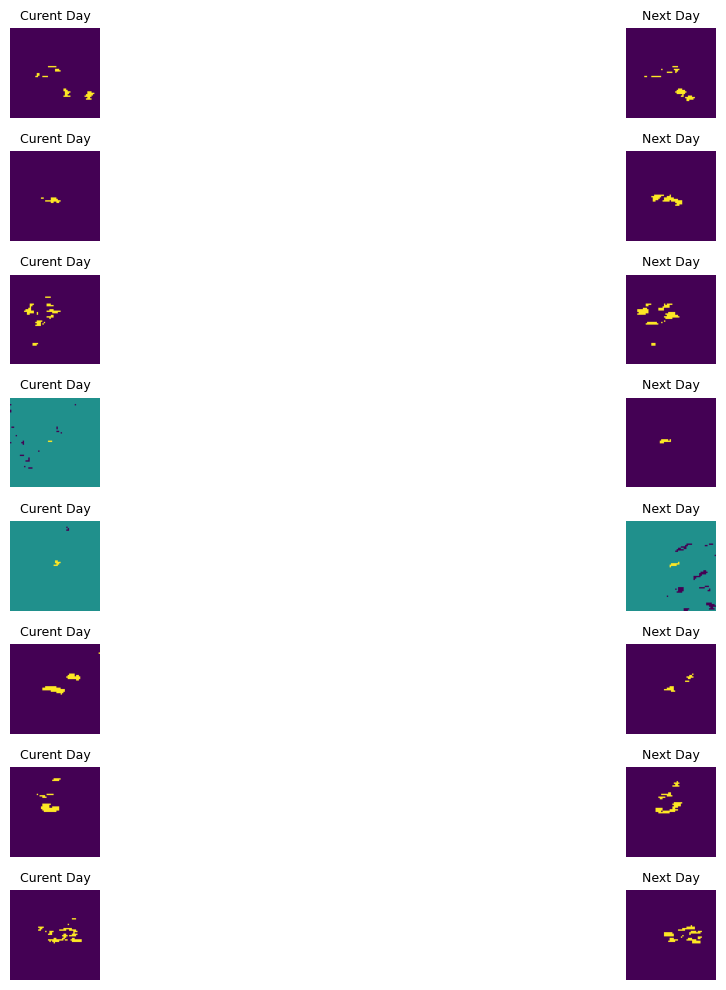

In [ ]:
fig, axes = plt.subplots(8, 2, figsize=(18, 10))

for i, (x, y) in enumerate(train_ds):
    if i >= 8:
        break
    axes[i][0].imshow(x[:, :, 0].numpy(), cmap='viridis')
    axes[i][0].set_title("Curent Day", fontsize=9)

    axes[i][1].imshow(y[:, :, 0].numpy(), cmap='viridis')
    axes[i][1].set_title("Next Day", fontsize=9)

    axes[i][0].axis('off')
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

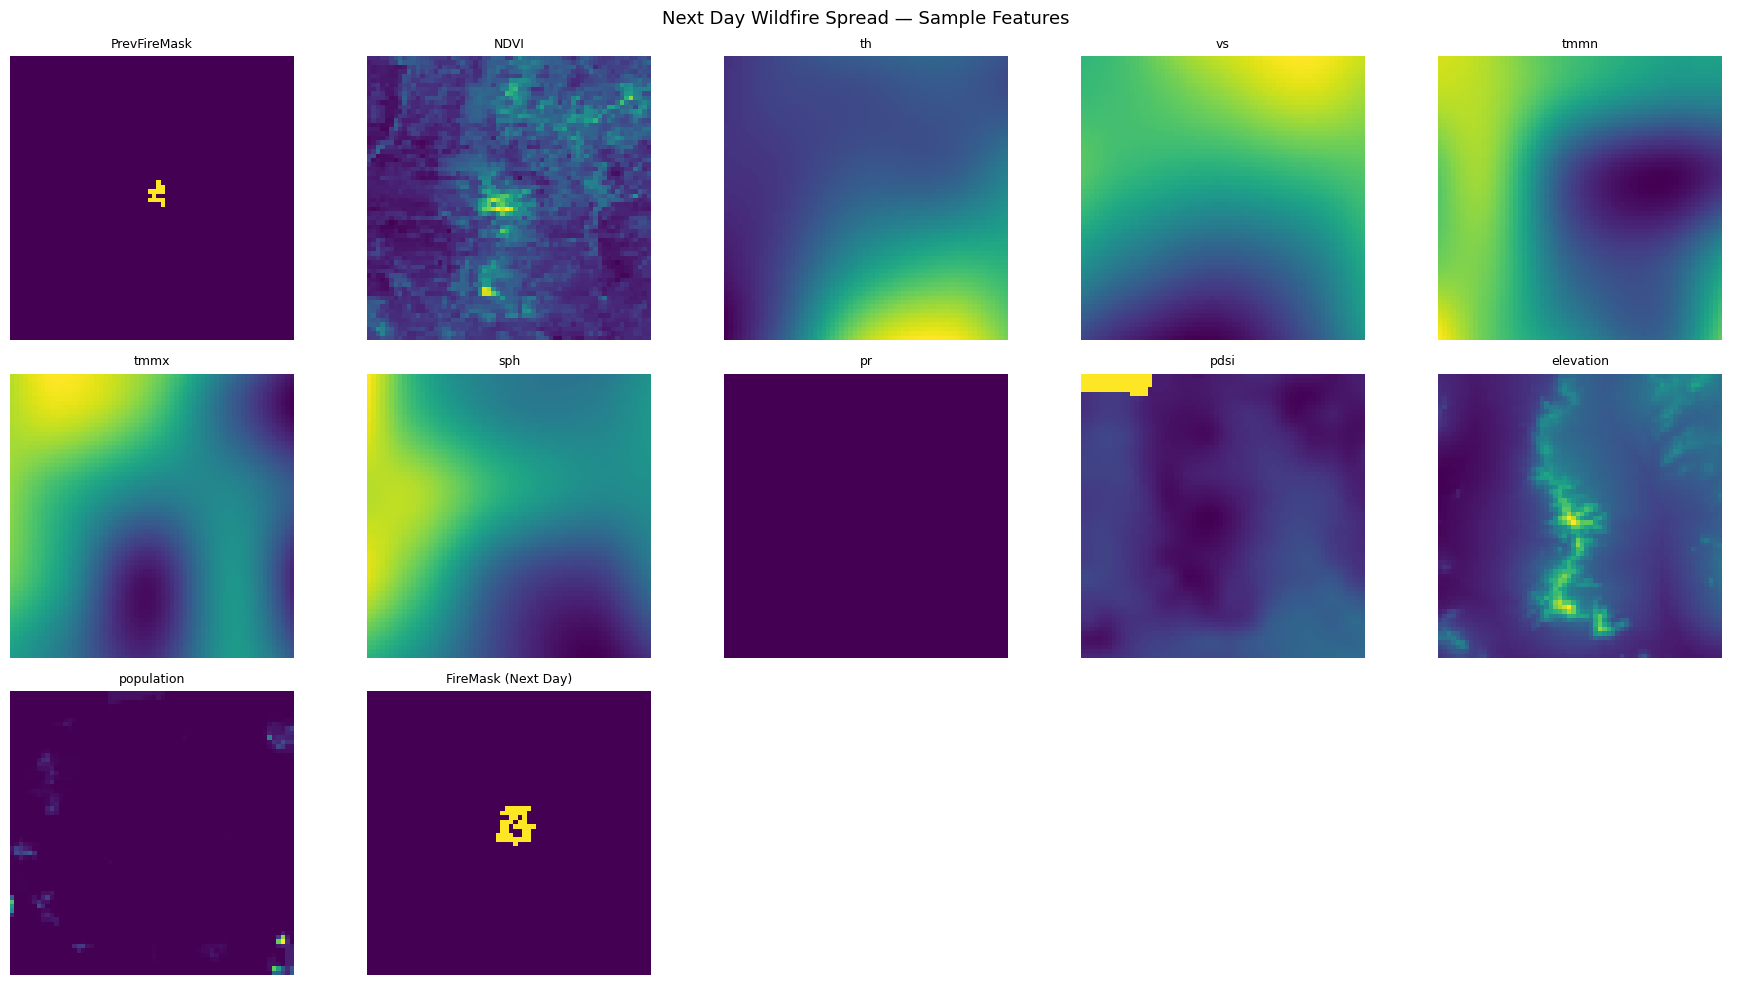

In [ ]:
for x_batch, y_batch in train_ds.take(1):
    visualize_sample(x_batch, y_batch)

In [ ]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 64, 64, 11), dtype=tf.float32, name=None), TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None))


### Feature Distributions: Box Plots and Histograms

These plots help visualize the statistical distribution of each input feature. A box plot shows the median, quartiles, and potential outliers, while a histogram displays the frequency distribution of values.

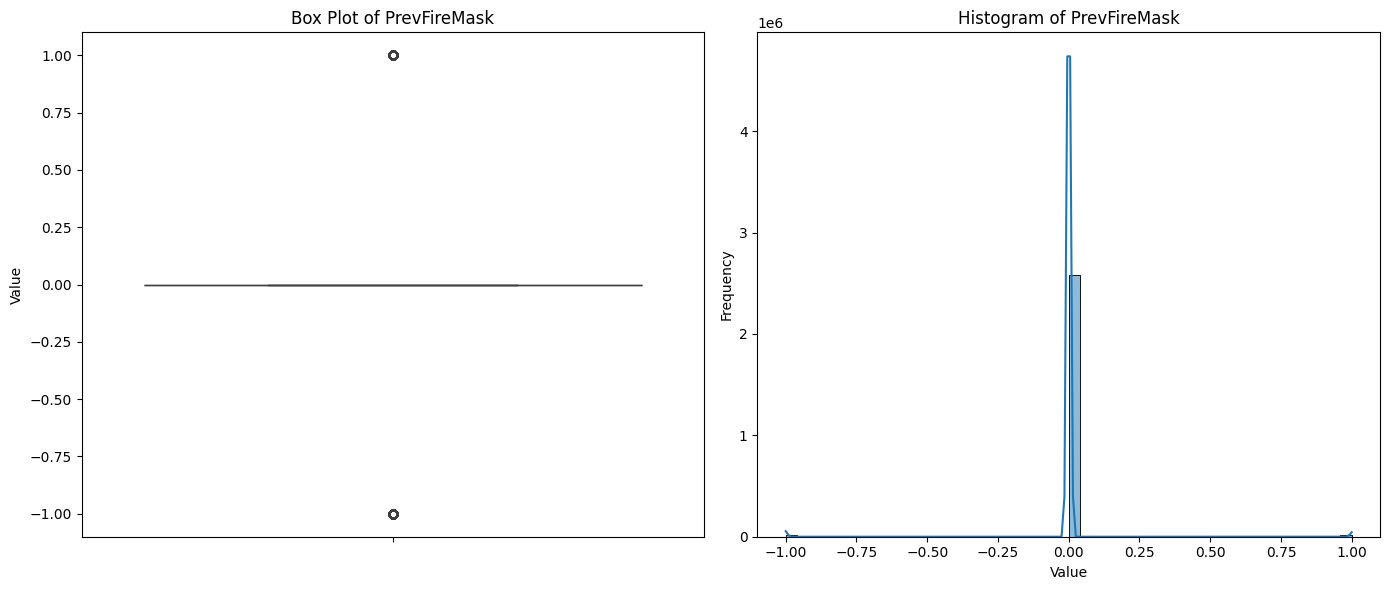

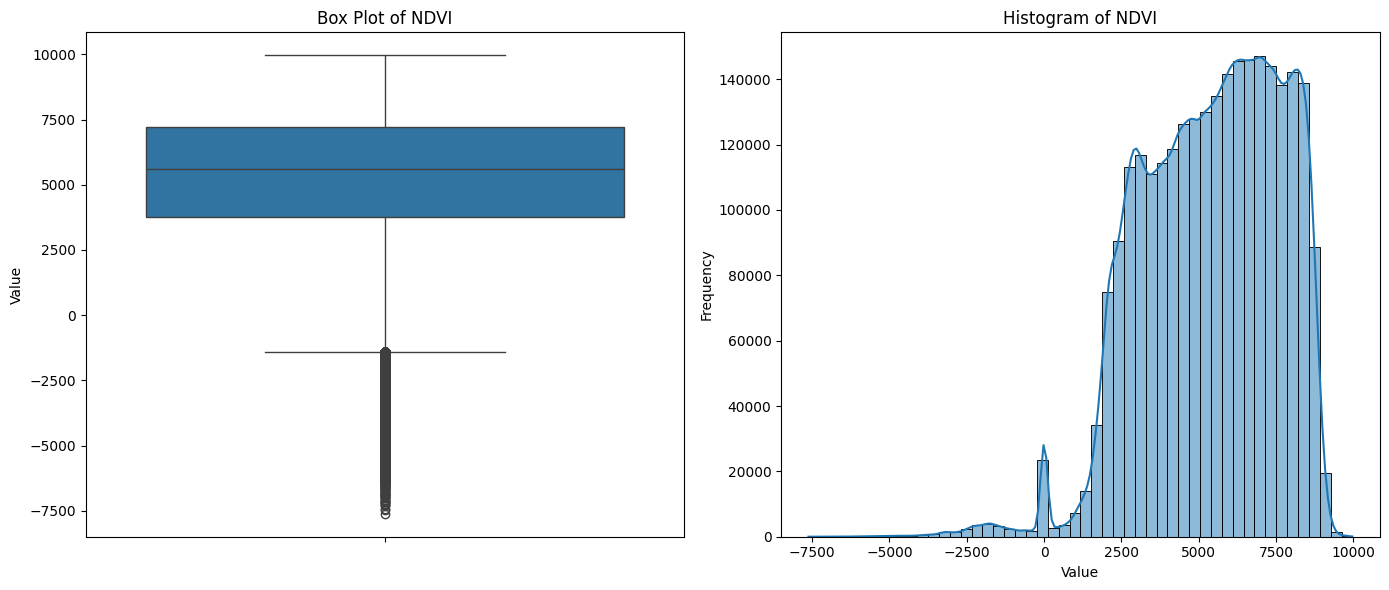

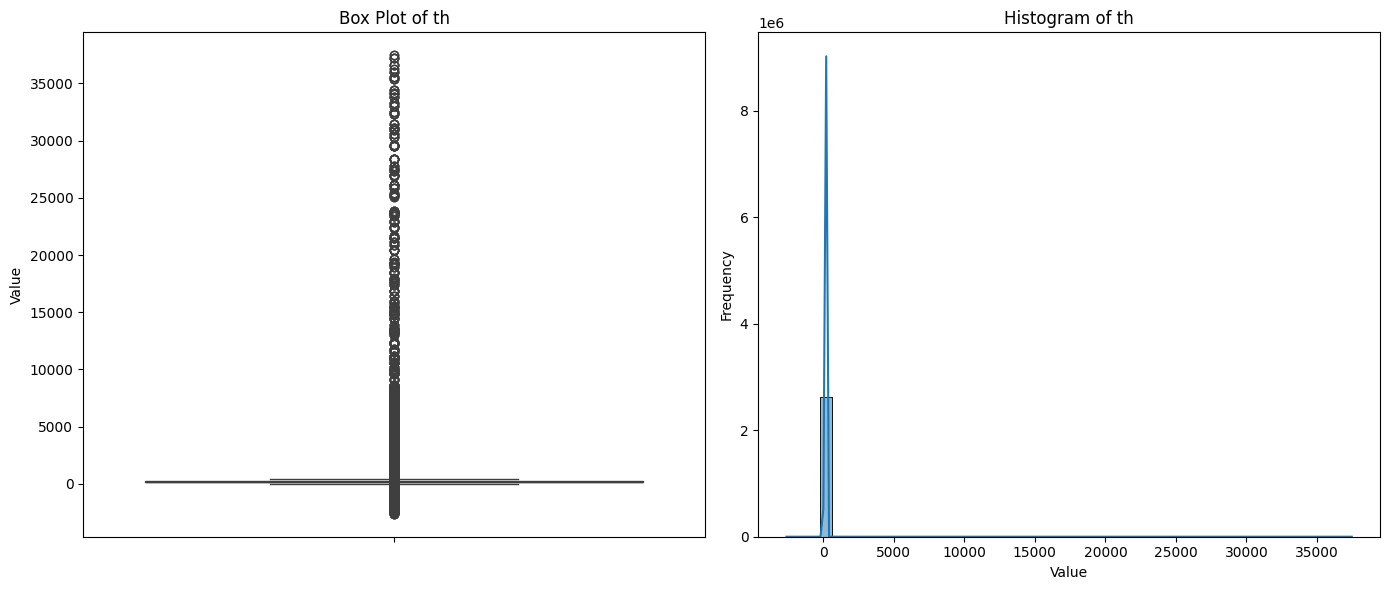

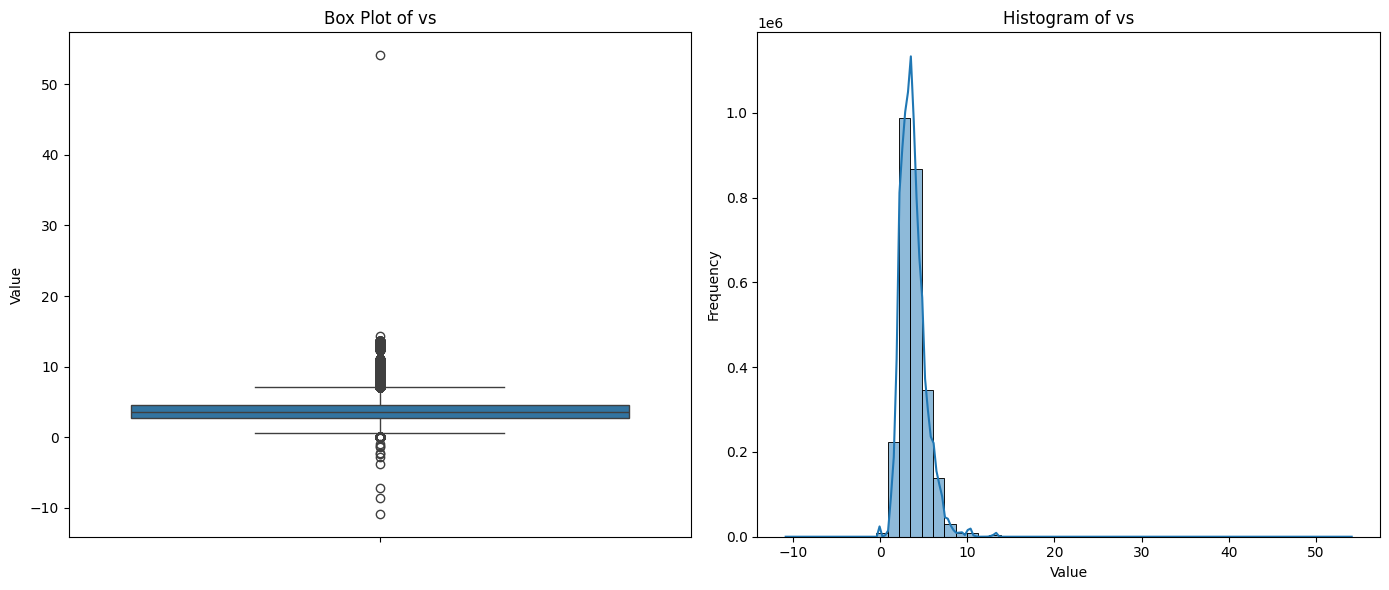

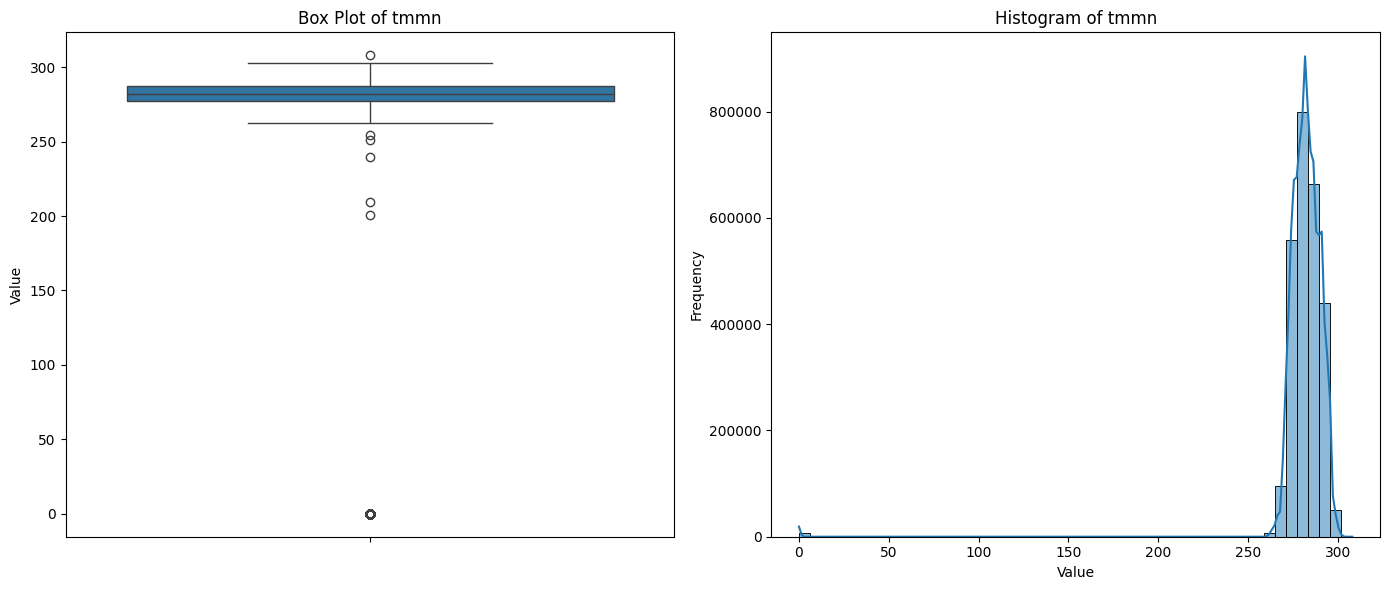

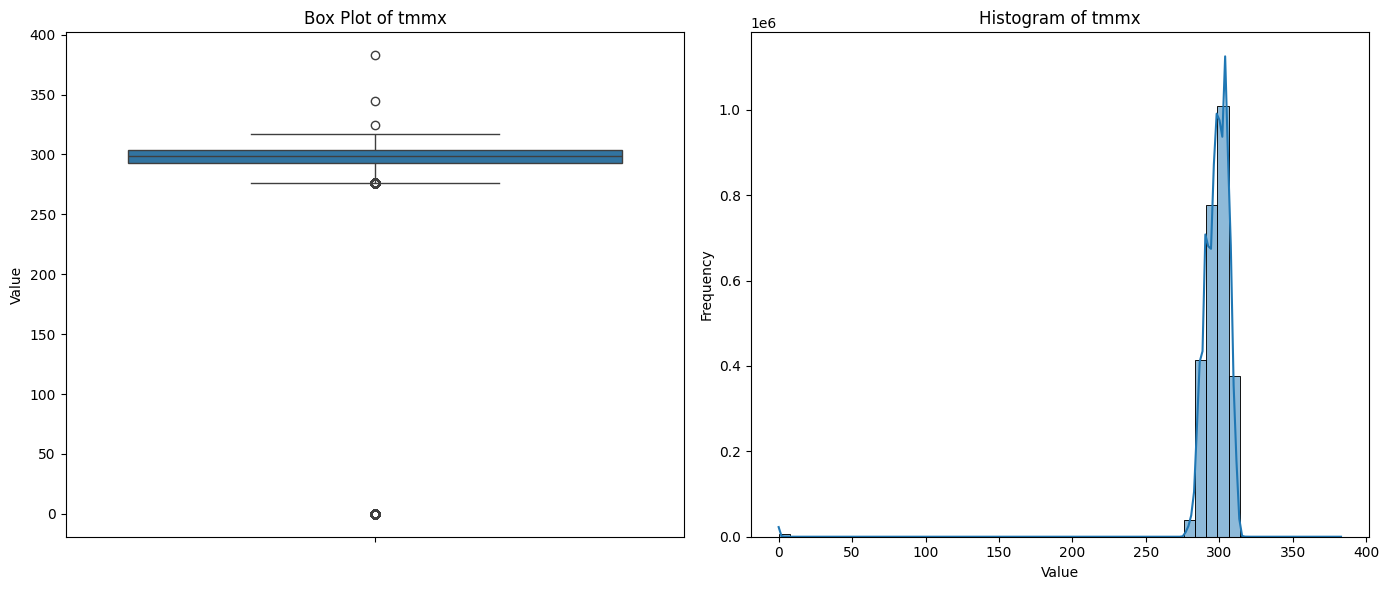

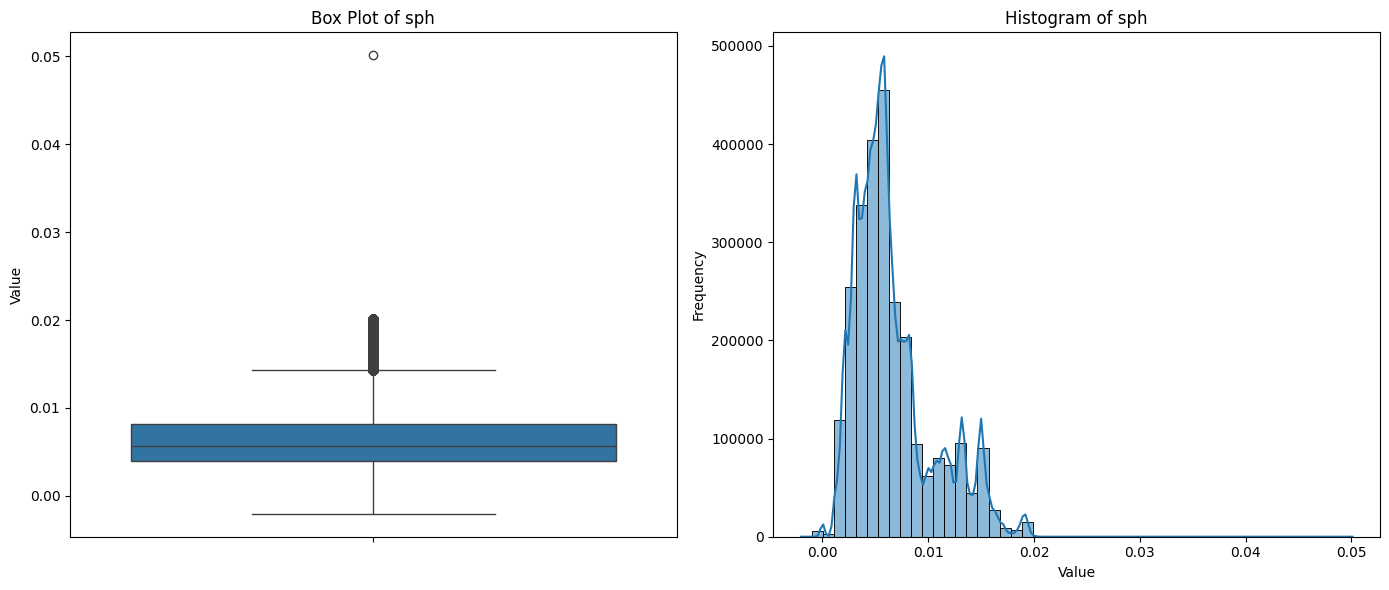

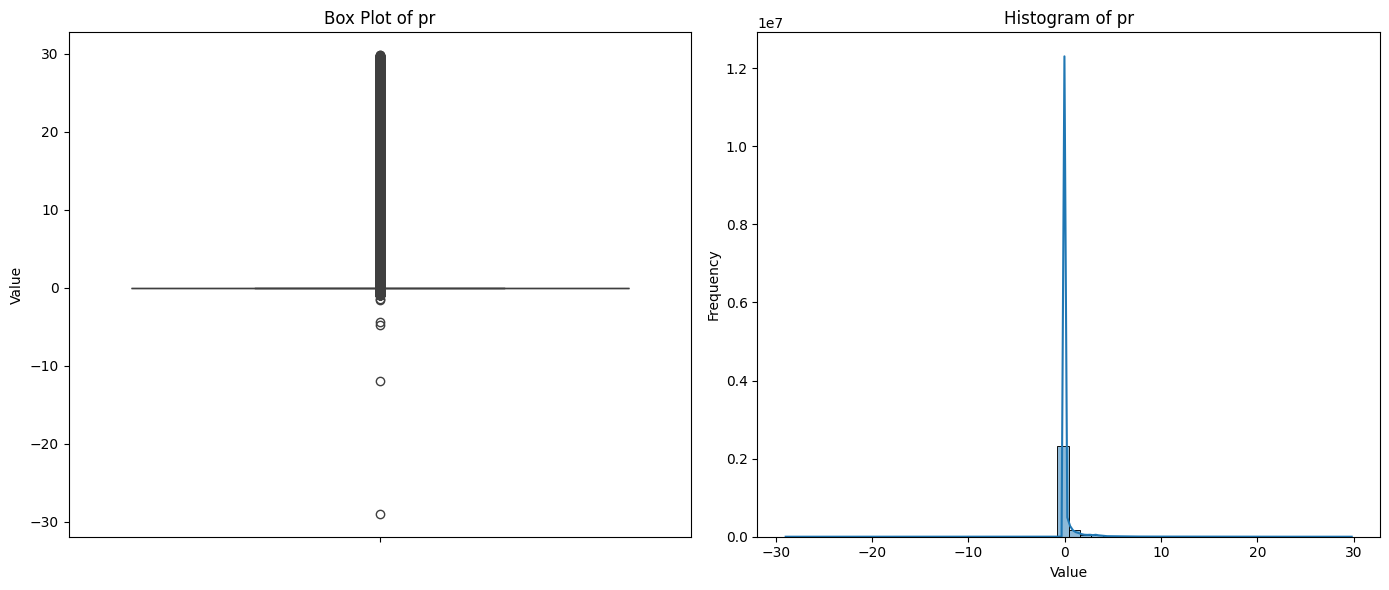

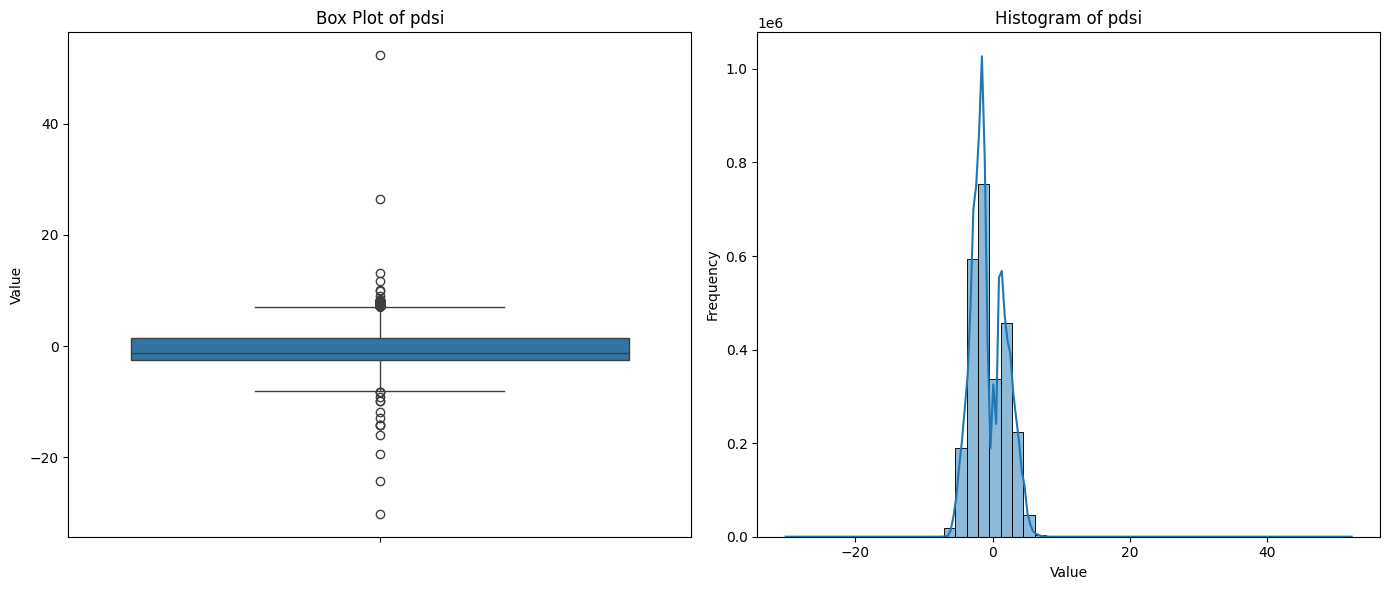

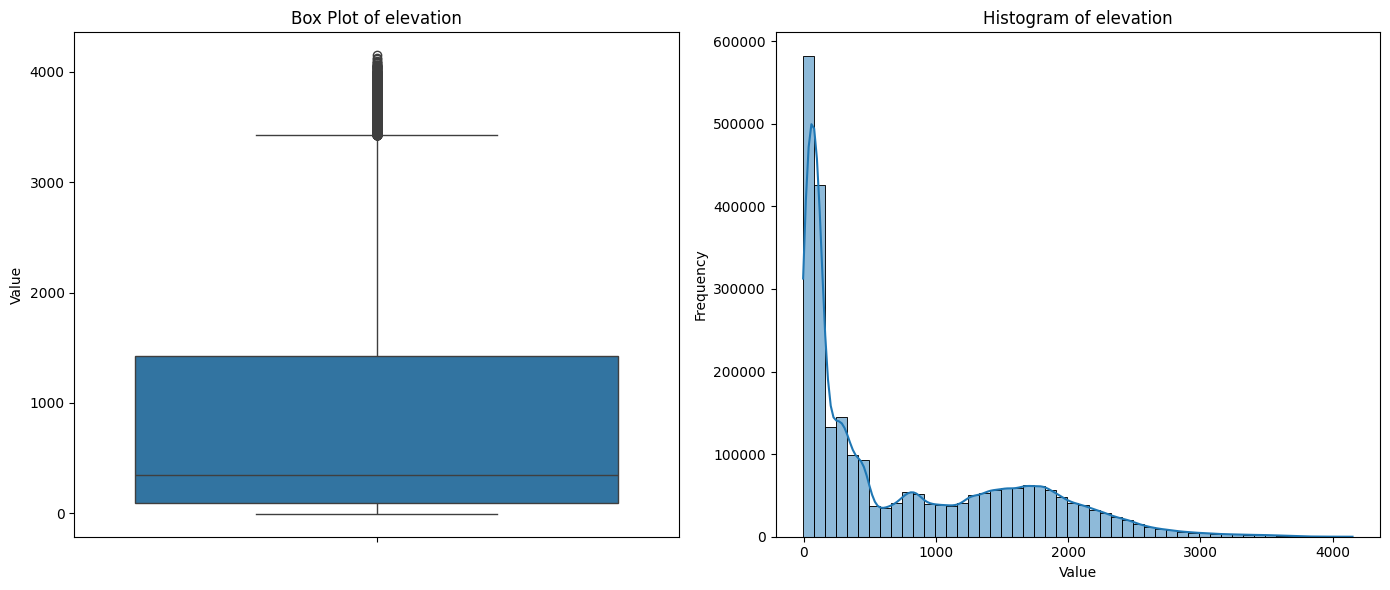

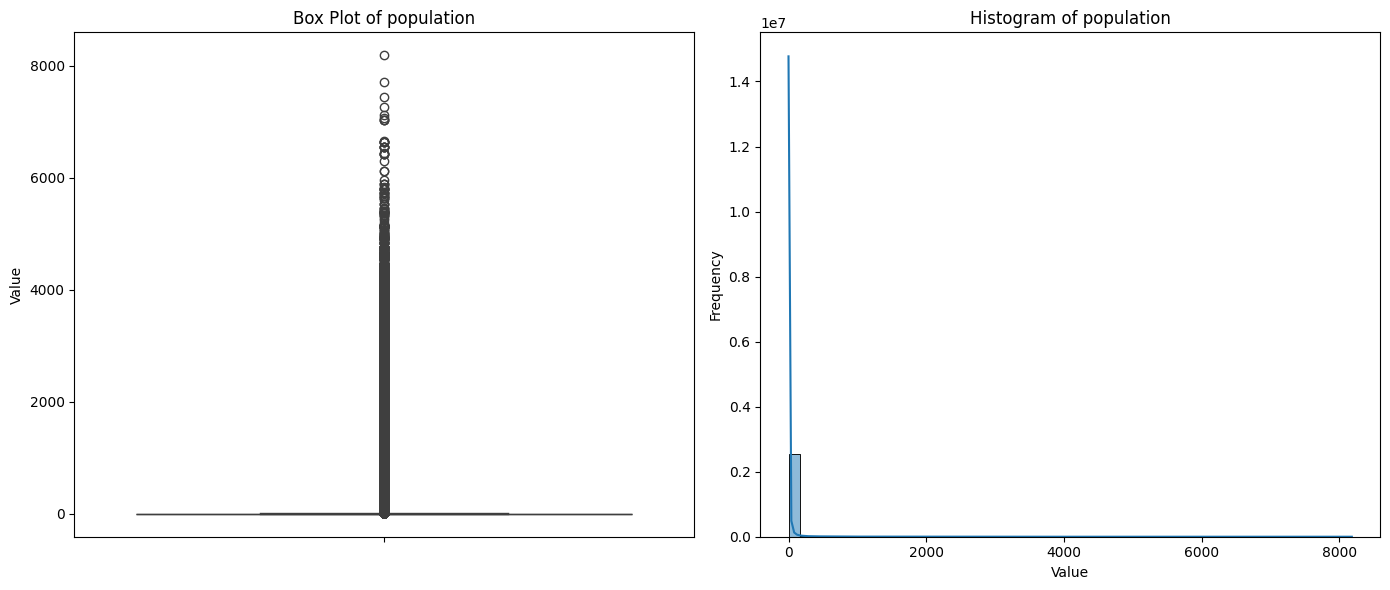

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper function to get a sample of data for visualization
def get_sample_data_for_visualization(dataset, num_batches=20):
    all_data = []
    for x, _ in dataset.take(num_batches):
        all_data.append(x.numpy())
    # Concatenate along the batch dimension to get a large sample of feature data
    return np.concatenate(all_data, axis=0)

# Get a sample of data from the training dataset
sample_data = get_sample_data_for_visualization(train_ds)

# Iterate through each input feature to create plots
for i, feat_name in enumerate(INPUT_FEATURES):
    # Extract data for the current feature and flatten it
    feature_data = sample_data[..., i].flatten()

    plt.figure(figsize=(14, 6))

    # Subplot 1: Box Plot
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    sns.boxplot(y=feature_data)
    plt.title(f'Box Plot of {feat_name}')
    plt.ylabel('Value')

    # Subplot 2: Histogram (acting as a bar graph for distribution)
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    sns.histplot(feature_data, kde=True, bins=50) # bins can be adjusted as needed
    plt.title(f'Histogram of {feat_name}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [ ]:
sample_data.shape

print(sample_data.)

(640, 64, 64, 11)

In [ ]:
cardinality = tf.data.experimental.cardinality(train_ds)

if cardinality == tf.data.UNKNOWN_CARDINALITY:
    print("The cardinality of the dataset is unknown. Counting batches by iteration...")
    num_batches = 0
    for _ in train_ds:
        num_batches += 1
    print(f"The 'train_ds' contains {num_batches} batches.")
else:
    num_batches = cardinality.numpy()
    print(f"The 'train_ds' contains {num_batches} batches.")

The cardinality of the dataset is unknown. Counting batches by iteration...
The 'train_ds' contains 469 batches.


In [ ]:
for raw_record in tf.data.TFRecordDataset('/content/ndws_data/next_day_wildfire_spread_eval_00.tfrecord').take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print(example.features.feature.keys())


In [ ]:
result = {}
# example.features.feature is the dictionary
for key, feature in example.features.feature.items():
  # The values are the Feature objects which contain a `kind` which contains:
  # one of three fields: bytes_list, float_list, int64_list

  kind = feature.WhichOneof('kind')
  print(key, kind)
  result[key] = np.array(getattr(feature, kind).value)

result

tmmn float_list
NDVI float_list
FireMask float_list
population float_list
elevation float_list
vs float_list
pdsi float_list
pr float_list
tmmx float_list
sph float_list
th float_list
PrevFireMask float_list
erc float_list


{'tmmn': array([279.3722229 , 279.37597656, 279.38027954, ..., 277.7310791 ,
        277.74533081, 277.75964355]),
 'NDVI': array([5567., 5664., 5379., ..., 5162., 4169., 4169.]),
 'FireMask': array([0., 0., 0., ..., 0., 0., 0.]),
 'population': array([ 1.47660875,  1.47660911,  1.47660899, ..., 39.25423431,
        39.43015289, 39.43014526]),
 'elevation': array([ 88.,  86.,  87., ..., 109., 106., 102.]),
 'vs': array([3.74688745, 3.74703455, 3.74708414, ..., 3.95306659, 3.95721984,
        3.96245885]),
 'pdsi': array([2.67828178, 2.6691072 , 2.65529227, ..., 3.77156568, 3.76690292,
        3.75934267]),
 'pr': array([6.45809317, 6.48646212, 6.50590754, ..., 5.96996975, 5.98822021,
        6.00347567]),
 'tmmx': array([293.8444519 , 293.85745239, 293.87109375, ..., 292.26135254,
        292.27383423, 292.28552246]),
 'sph': array([0.00907956, 0.00908028, 0.00908092, ..., 0.00797545, 0.00797619,
        0.0079763 ]),
 'th': array([144.67245483, 144.66702271, 144.63694763, ..., 153.064

In [ ]:
for key in result:
  result[key] = result[key].reshape((64, 64))

In [ ]:
print(list(result.keys()))

['tmmn', 'NDVI', 'FireMask', 'population', 'elevation', 'vs', 'pdsi', 'pr', 'tmmx', 'sph', 'th', 'PrevFireMask', 'erc']


TS-SatFire Dataset

In [ ]:
!kaggle datasets download -d z789456sx/ts-satfire

Dataset URL: https://www.kaggle.com/datasets/z789456sx/ts-satfire
License(s): Attribution 4.0 International (CC BY 4.0)
100% 69.1G/69.1G [12:57<00:00, 95.5MB/s]



In [ ]:
!unzip -l ts-satfire.zip | head -100

Archive:  ts-satfire.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
 18982114  2025-10-26 05:18   ts-satfire/20562846/ESRI_LULC/2017-01-01_ESRI_LULC.tif
  6774729  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-23_FirePred.tif
  6897905  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-24_FirePred.tif
  6880985  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-25_FirePred.tif
  6968041  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-26_FirePred.tif
  6912446  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-27_FirePred.tif
  6979093  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-28_FirePred.tif
  6909339  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-29_FirePred.tif
  6856283  2025-10-26 05:18   ts-satfire/20562846/FirePred/2017-04-30_FirePred.tif
  7708268  2025-10-26 05:18   ts-satfire/20562846/VIIRS_Day/2017-04-23_VIIRS_Day.tif
  7762506  2025-10-26 05:18   ts-satfire/20562846/VIIRS_Day/2017-04-24_

In [ ]:
!unzip ts-satfire.zip "ts-satfire/20562846/*" -d data/

Archive:  ts-satfire.zip
  inflating: data/ts-satfire/20562846/ESRI_LULC/2017-01-01_ESRI_LULC.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-23_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-24_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-25_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-26_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-27_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-28_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-29_FirePred.tif  
  inflating: data/ts-satfire/20562846/FirePred/2017-04-30_FirePred.tif  
  inflating: data/ts-satfire/20562846/VIIRS_Day/2017-04-23_VIIRS_Day.tif  
  inflating: data/ts-satfire/20562846/VIIRS_Day/2017-04-24_VIIRS_Day.tif  
  inflating: data/ts-satfire/20562846/VIIRS_Day/2017-04-25_VIIRS_Day.tif  
  inflating: data/ts-satfire/20562846/VIIRS_Day/2017-04-26_VIIRS_Day.tif  
  inflating: dat

In [ ]:
!rm ts-satfire.zip

In [ ]:
import rasterio

with rasterio.open("data/ts-satfire/20562846/VIIRS_Day/2017-04-24_VIIRS_Day.tif") as src:
  img = src.read()
  print(img.shape)

img[3, :, :].shape

(8, 595, 595)


(595, 595)

In [ ]:
import numpy as np

In [ ]:
i4 = img[3, :, :].copy()

mask = i4 >= 325
# mask2 = img > 1
masked_arr = np.where(mask, 1, 0)
# masked_arr = np.where(masked_arr, mask2, 0)

In [ ]:
masked_arr

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])